In [ ]:
import pandas as pd
import numpy as np
import sklearn
import keras
import matplotlib.pyplot as plt
from keras import regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from keras.layers import Input, Dropout, Dense, BatchNormalization
from keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from keras.callbacks import EarlyStopping

In [3]:
# Lista oficial de colunas conforme a documentação da UCI
columns = [
    'Elevation', 'Aspect', 'Slope', 
    'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 
    'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points'
]

# Adicionando as colunas binárias de Wilderness_Area (4 colunas)
columns += [f'Wilderness_Area_{i}' for i in range(4)]

# Adicionando as colunas binárias de Soil_Type (40 colunas)
columns += [f'Soil_Type_{i}' for i in range(40)]

# Adicionando a coluna alvo
columns.append('Cover_Type')

# Importando com os nomes definidos
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/covtype/covtype.data.gz"
data = pd.read_csv(url, header=None, names=columns)

data

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581007,2396,153,20,85,17,108,240,237,118,837,...,0,0,0,0,0,0,0,0,0,3
581008,2391,152,19,67,12,95,240,237,119,845,...,0,0,0,0,0,0,0,0,0,3
581009,2386,159,17,60,7,90,236,241,130,854,...,0,0,0,0,0,0,0,0,0,3
581010,2384,170,15,60,5,90,230,245,143,864,...,0,0,0,0,0,0,0,0,0,3


In [4]:
data['Cover_Type'] = data['Cover_Type'] - 1
data['Cover_Type'].value_counts()

Cover_Type
1    283301
0    211840
2     35754
6     20510
5     17367
4      9493
3      2747
Name: count, dtype: int64

In [5]:
X = np.array(data.drop(['Cover_Type'], axis = 1))
y = np.array(data['Cover_Type'])

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, random_state = 42, test_size = 0.2)
X_treino, X_val, y_treino, y_val = train_test_split(X_treino, y_treino, random_state = 42, test_size = 0.2)

scaler = MinMaxScaler()

X_treino = scaler.fit_transform(X_treino)
X_val = scaler.fit_transform(X_val)
X_teste  = scaler.transform(X_teste)

In [6]:
def ModelagemRC(X_train, y_train, X_test, Modelo):
    
    Modelo.fit(X_train, y_train)
    
    return Modelo.predict(X_test)

In [ ]:
modelo = RandomForestClassifier(random_state=42)

random_forest_predict = ModelagemRC(X_treino, y_treino, X_teste, modelo)

print(classification_report(y_teste, random_forest_predict))

              precision    recall  f1-score   support

           0       0.95      0.94      0.95     42557
           1       0.94      0.97      0.95     56500
           2       0.94      0.96      0.95      7121
           3       0.91      0.82      0.86       526
           4       0.94      0.73      0.82      1995
           5       0.93      0.88      0.91      3489
           6       0.96      0.95      0.95      4015

    accuracy                           0.95    116203
   macro avg       0.94      0.89      0.91    116203
weighted avg       0.95      0.95      0.95    116203



In [8]:
Ct = data.shape[0]
d = data.shape[1]

n = (Ct - 10) / (10 * (d + 2))
n = int(n)

n

1019

In [ ]:
model = Sequential()

# Entrada
model.add(Input(shape=(54,)))

# Camadas escondidas
model.add(Dense(500, kernel_initializer='normal', kernel_regularizer=regularizers.l2(0.0001), activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(500, kernel_initializer='normal', kernel_regularizer=regularizers.l2(0.0001), activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# Camada de saída
model.add(Dense(7, kernel_initializer='normal', activation='softmax'))

# Obtém os pesos iniciais da rede
initial_weights = model.get_weights()

es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10)
# Compila o modelo
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 500)            │        27,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 500)            │         2,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 500)            │       250,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 500)            │         2,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │         3,507 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 285,507 (1.09 MB)

 Trainable params: 283,507 (1.08 MB)

 Non-trainable params: 2,000 (7.81 KB)

None


In [18]:
model.set_weights(initial_weights)
history = model.fit(X_treino, y_treino, epochs=100, batch_size=1024, validation_data=(X_val, y_val), callbacks=[es])

Epoch 1/100
364/364 ━━━━━━━━━━━━━━━━━━━━ 46s 97ms/step - accuracy: 0.7244 - loss: 0.7722 - val_accuracy: 0.5246 - val_loss: 1.0598
Epoch 2/100
364/364 ━━━━━━━━━━━━━━━━━━━━ 36s 98ms/step - accuracy: 0.7712 - loss: 0.5821 - val_accuracy: 0.7875 - val_loss: 0.5412
Epoch 3/100
364/364 ━━━━━━━━━━━━━━━━━━━━ 57s 157ms/step - accuracy: 0.7947 - loss: 0.5224 - val_accuracy: 0.8221 - val_loss: 0.4641
Epoch 4/100
364/364 ━━━━━━━━━━━━━━━━━━━━ 35s 95ms/step - accuracy: 0.8115 - loss: 0.4823 - val_accuracy: 0.8292 - val_loss: 0.4408
Epoch 5/100
364/364 ━━━━━━━━━━━━━━━━━━━━ 51s 139ms/step - accuracy: 0.8236 - loss: 0.4550 - val_accuracy: 0.8458 - val_loss: 0.4124
Epoch 6/100
364/364 ━━━━━━━━━━━━━━━━━━━━ 57s 154ms/step - accuracy: 0.8332 - loss: 0.4328 - val_accuracy: 0.8522 - val_loss: 0.3908
Epoch 7/100
364/364 ━━━━━━━━━━━━━━━━━━━━ 66s 180ms/step - accuracy: 0.8400 - loss: 0.4175 - val_accuracy: 0.8604 - val_loss: 0.3737
Epoch 8/100
364/364 ━━━━━━━━━━━━━━━━━━━━ 43s 118ms/step - accuracy: 0.8460 - lo

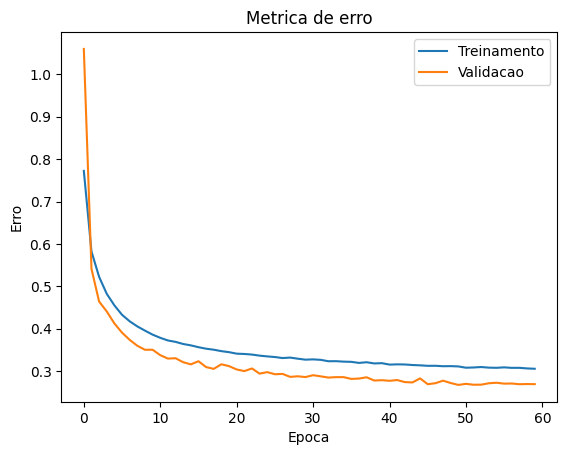

--> E_val - E_in = 0.0173
--> Acuracia (treino): 0.9215
--> Acuracia (validacao): 0.9135
--> acc_train - acc_test = 0.0080


In [19]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Metrica de erro')
plt.ylabel('Erro')
plt.xlabel('Epoca')
plt.legend(['Treinamento', 'Validacao'])
plt.show()

# Obtendo a acuracia no conjunto de treinamento
E_in, acc_train = model.evaluate(X_treino, y_treino, batch_size=64, verbose=0)

# Obtendo a acuracia no conjunto de validacao
E_val, acc_val = model.evaluate(X_val, y_val, batch_size=64, verbose=0)

print(f"--> E_val - E_in = {E_val - E_in:.4f}")
print(f'--> Acuracia (treino): {acc_train:.4f}')
print(f'--> Acuracia (validacao): {acc_val:.4f}')
print(f"--> acc_train - acc_test = {acc_train - acc_val:.4f}")

In [20]:
y_prob = model.predict(X_teste)

# 2. Pega o índice da classe com maior probabilidade (Ex: [0.1, 0.8, 0.1] -> Classe 1)
y_pred = np.argmax(y_prob, axis=1)

print(classification_report(y_teste, y_pred))

3632/3632 ━━━━━━━━━━━━━━━━━━━━ 25s 7ms/step
              precision    recall  f1-score   support

           0       0.91      0.90      0.91     42557
           1       0.92      0.93      0.92     56500
           2       0.93      0.93      0.93      7121
           3       0.85      0.86      0.85       526
           4       0.80      0.76      0.78      1995
           5       0.87      0.86      0.86      3489
           6       0.92      0.92      0.92      4015

    accuracy                           0.91    116203
   macro avg       0.89      0.88      0.88    116203
weighted avg       0.91      0.91      0.91    116203

